In [1]:
import urllib.request
import zipfile
import os
from pathlib import Path

url = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"
zip_path = "sms_spam_collection.zip"
extracted_path = "sms_spam_collection"
data_file_path = Path(extracted_path) / "SMSSpamCollection.tsv"

def download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path):
    if data_file_path.exists():
        print(f"{data_file_path} already exists. Skipping download and extraction.")
        return

    # Downloading the file
    with urllib.request.urlopen(url) as response:
        with open(zip_path, "wb") as out_file:
            out_file.write(response.read())

    # Unzipping the file
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extracted_path)

    # Add .tsv file extension
    original_file_path = Path(extracted_path) / "SMSSpamCollection"
    os.rename(original_file_path, data_file_path)
    print(f"File downloaded and saved as {data_file_path}")

try:
    download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path)
except (urllib.error.HTTPError, urllib.error.URLError, TimeoutError) as e:
    print(f"Primary URL failed: {e}. Trying backup URL...")
    url = "https://f001.backblazeb2.com/file/LLMs-from-scratch/sms%2Bspam%2Bcollection.zip"
    download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path)

File downloaded and saved as sms_spam_collection/SMSSpamCollection.tsv


In [2]:
import pandas as pd

df = pd.read_csv(data_file_path, sep="\t", header=None, names=["Label", "Text"])
df

,Label,Text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [3]:
print(df["Label"].value_counts())

Label
ham     4825
spam     747
Name: count, dtype: int64


In [4]:
def create_balanced_dataset(df):
    
    # Count the instances of "spam"
    num_spam = df[df["Label"] == "spam"].shape[0]
    
    # Randomly sample "ham" instances to match the number of "spam" instances
    ham_subset = df[df["Label"] == "ham"].sample(num_spam, random_state=123)
    
    # Combine ham "subset" with "spam"
    balanced_df = pd.concat([ham_subset, df[df["Label"] == "spam"]])

    return balanced_df


balanced_df = create_balanced_dataset(df)
print(balanced_df["Label"].value_counts())

Label
ham     747
spam    747
Name: count, dtype: int64


In [5]:
balanced_df["Label"] = balanced_df["Label"].map({"ham": 0, "spam": 1})    

In [6]:
balanced_df

,Label,Text
4307,0,Awww dat is sweet! We can think of something t...
4138,0,Just got to &lt;#&gt;
4831,0,"The word ""Checkmate"" in chess comes from the P..."
4461,0,This is wishing you a great day. Moji told me ...
5440,0,Thank you. do you generally date the brothas?
...,...,...
5537,1,Want explicit SEX in 30 secs? Ring 02073162414...
5540,1,ASKED 3MOBILE IF 0870 CHATLINES INCLU IN FREE ...
5547,1,Had your contract mobile 11 Mnths? Latest Moto...
5566,1,REMINDER FROM O2: To get 2.50 pounds free call...


In [7]:
def random_split(df, train_frac, validation_frac):
    # Shuffle the entire DataFrame
    df = df.sample(frac=1, random_state=123).reset_index(drop=True)

    # Calculate split indices
    train_end = int(len(df) * train_frac)
    validation_end = train_end + int(len(df) * validation_frac)

    # Split the DataFrame
    train_df = df[:train_end]
    validation_df = df[train_end:validation_end]
    test_df = df[validation_end:]

    return train_df, validation_df, test_df

train_df, validation_df, test_df = random_split(balanced_df, 0.7, 0.1)
# Test size is implied to be 0.2 as the remainder

train_df.to_csv("train.csv", index=None)
validation_df.to_csv("validation.csv", index=None)
test_df.to_csv("test.csv", index=None)

In [8]:
import mlx.core as mx
import mlx.data as mdx
import tiktoken

tokenizer = tiktoken.get_encoding("gpt2")
print(tokenizer.encode("<|endoftext|>", allowed_special={"<|endoftext|>"}))

[50256]


In [9]:
from mlxgpt.dataloader import create_spam_dataset

train_buffer, max_length = create_spam_dataset(
    csv_file="train.csv",
    max_length=None,
    tokenizer=tokenizer
)

print(max_length)

120


In [10]:
def decode_text(token_list: list, tokenizer=tokenizer, pad_token_id=50256):
    """Helper function to decode tokens to text"""
    if pad_token_id in token_list:
        pad_idx = token_list.index(pad_token_id)
        token_list = token_list[:pad_idx]
    return tokenizer.decode(token_list).encode(encoding='utf-8')

s = train_buffer.sample_transform(lambda s: {**s, 'text': decode_text(s['input'].tolist())}).to_stream()
for i in range(3):
    sample = next(s)
    print(f"label: {sample['label']}, text: {sample['text'].tobytes().decode('utf-8')}")

s1 = train_buffer.key_transform('input', lambda x: list(decode_text(x.tolist())), 'text').to_stream()
for i in range(2):
    sample = next(s1)
    print(f"label: {sample['label']}, text: {sample['text'].tobytes().decode('utf-8')}")


label: 0, text: Dude how do you like the buff wind.
label: 0, text: Tessy..pls do me a favor. Pls convey my birthday wishes to Nimya..pls dnt forget it. Today is her birthday Shijas
label: 1, text: Reminder: You have not downloaded the content you have already paid for. Goto http://doit. mymoby. tv/ to collect your content.
label: 0, text: D       u       d       e               h       o       w               d       o               y       o       u               l       i       k       e               t       h       e               b       u       f       f               w       i       n       d       .       
label: 0, text: T       e       s       s       y       .       .       p       l       s               d       o               m       e               a               f       a       v       o       r       .               P       l       s               c       o       n       v       e       y               m       y               b       i       r       t       h       d

In [11]:
from mlxgpt.dataloader import create_spam_dataset

val_buffer, _ = create_spam_dataset(
    csv_file="validation.csv",
    max_length=max_length,
    tokenizer=tokenizer
)
test_buffer, _ = create_spam_dataset(
    csv_file="test.csv",
    max_length=max_length,
    tokenizer=tokenizer
)

In [12]:
from mlxgpt.dataloader import MLXDataLoader

train_loader = MLXDataLoader(
    dataset=train_buffer,
    batch_size=8,
    shuffle=True,
    drop_last=True
)

val_loader = MLXDataLoader(
    dataset=val_buffer,
    batch_size=8,
    shuffle=False,
    drop_last=False
)

test_loader = MLXDataLoader(
    dataset=test_buffer,
    batch_size=8,
    shuffle=False,
    drop_last=False
)

In [13]:
print("Train loader:")
length = 0
for (input_batch, target_batch) in train_loader:
    length += 1

print("Number of batches in train loader:", length)
print("Input batch dimensions:", input_batch.shape)
print("Label batch dimensions", target_batch.shape)

Train loader:
Number of batches in train loader: 130
Input batch dimensions: (8, 120)
Label batch dimensions (8,)


In [14]:
print(f"{len(train_loader)} training batches")
print(f"{len(val_loader)} validation batches")
print(f"{len(test_loader)} test batches")

130 training batches
19 validation batches
38 test batches


In [15]:
from mlxgpt.model import create_gpt_model, GPTModel

# Create model
model: GPTModel = create_gpt_model("small")

Loading gpt2-small (124M) model from cache...
Model loaded successfully from gpt2/GPT2-small.npz


In [16]:
from mlxgpt.gpt2 import generate_text_simple, text_to_token_ids, token_ids_to_text

text_1 = "Every effort moves you"

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(text_1, tokenizer),
    max_new_tokens=15,
    context_size=model.context_length
)

print(token_ids_to_text(token_ids, tokenizer))

Every effort moves you to make the game.

The game is a game of the mind


In [17]:
model.freeze()
model.trainable_parameters()

{'tok_emb': {},
 'pos_emb': {},
 'drop_emb': {},
 'trf_blocks': {'layers': [{'att': {'W_query': {},
     'W_key': {},
     'W_value': {},
     'out_proj': {},
     'dropout': {}},
    'ff': {'layers': {'layers': [{}, {}, {}]}},
    'norm1': {},
    'norm2': {},
    'drop_shortcut': {}},
   {'att': {'W_query': {},
     'W_key': {},
     'W_value': {},
     'out_proj': {},
     'dropout': {}},
    'ff': {'layers': {'layers': [{}, {}, {}]}},
    'norm1': {},
    'norm2': {},
    'drop_shortcut': {}},
   {'att': {'W_query': {},
     'W_key': {},
     'W_value': {},
     'out_proj': {},
     'dropout': {}},
    'ff': {'layers': {'layers': [{}, {}, {}]}},
    'norm1': {},
    'norm2': {},
    'drop_shortcut': {}},
   {'att': {'W_query': {},
     'W_key': {},
     'W_value': {},
     'out_proj': {},
     'dropout': {}},
    'ff': {'layers': {'layers': [{}, {}, {}]}},
    'norm1': {},
    'norm2': {},
    'drop_shortcut': {}},
   {'att': {'W_query': {},
     'W_key': {},
     'W_value': {},
  

In [18]:
import mlx.nn as nn

num_classes = 2
model.out_head = nn.Linear(model.tok_emb.weight.shape[1], num_classes, bias=True)

In [19]:
model['final_norm'].unfreeze()
model['trf_blocks'].layers[-1].unfreeze()
model.trainable_parameters()

{'tok_emb': {},
 'pos_emb': {},
 'drop_emb': {},
 'trf_blocks': {'layers': [{'att': {'W_query': {},
     'W_key': {},
     'W_value': {},
     'out_proj': {},
     'dropout': {}},
    'ff': {'layers': {'layers': [{}, {}, {}]}},
    'norm1': {},
    'norm2': {},
    'drop_shortcut': {}},
   {'att': {'W_query': {},
     'W_key': {},
     'W_value': {},
     'out_proj': {},
     'dropout': {}},
    'ff': {'layers': {'layers': [{}, {}, {}]}},
    'norm1': {},
    'norm2': {},
    'drop_shortcut': {}},
   {'att': {'W_query': {},
     'W_key': {},
     'W_value': {},
     'out_proj': {},
     'dropout': {}},
    'ff': {'layers': {'layers': [{}, {}, {}]}},
    'norm1': {},
    'norm2': {},
    'drop_shortcut': {}},
   {'att': {'W_query': {},
     'W_key': {},
     'W_value': {},
     'out_proj': {},
     'dropout': {}},
    'ff': {'layers': {'layers': [{}, {}, {}]}},
    'norm1': {},
    'norm2': {},
    'drop_shortcut': {}},
   {'att': {'W_query': {},
     'W_key': {},
     'W_value': {},
  

In [20]:
inputs = text_to_token_ids("Do you have time", tokenizer)
print("Inputs:", inputs)
print("Inputs dimensions:", inputs.shape) # shape: (batch_size, num_tokens)

Inputs: array([[5211, 345, 423, 640]], dtype=int32)
Inputs dimensions: (1, 4)


In [21]:
outputs = model(inputs)

print("Outputs:\n", outputs)
print("Outputs dimensions:", outputs.shape) # shape: (batch_size, num_tokens, num_classes)

Outputs:
 array([[[-1.86613, 1.68363],
        [-4.20723, 1.98481],
        [-2.62674, -0.579785],
        [-1.46452, -1.24413]]], dtype=float32)
Outputs dimensions: (1, 4, 2)


In [22]:
print("Last output token:", outputs[:, -1, :])

Last output token: array([[-1.46452, -1.24413]], dtype=float32)


In [23]:
probas = mx.softmax(outputs[:, -1, :], axis=-1)
label = mx.argmax(probas)
print("Class label:", label.item())

Class label: 1


In [24]:
logits = outputs[:, -1, :]
label = mx.argmax(logits)
print("Class label:", label.item())

Class label: 1


In [25]:
def calc_accuracy_loader(data_loader, model, num_batches=None):
    model.eval()
    correct_predictions, num_examples = 0, 0

    if num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            outputs = model(input_batch)
            logits = outputs[:, -1, :]  # Logits of last output token
            predicted_labels = mx.argmax(logits, axis=-1)

            num_examples += predicted_labels.shape[0]
            correct_predictions += (predicted_labels == target_batch).sum().item()
        else:
            break
    return correct_predictions / num_examples

In [26]:
train_accuracy = calc_accuracy_loader(train_loader, model, num_batches=10)
val_accuracy = calc_accuracy_loader(val_loader, model, num_batches=10)
test_accuracy = calc_accuracy_loader(test_loader, model, num_batches=10)

print(f"Training accuracy: {train_accuracy*100:.2f}%")
print(f"Validation accuracy: {val_accuracy*100:.2f}%")
print(f"Test accuracy: {test_accuracy*100:.2f}%")

Training accuracy: 57.50%
Validation accuracy: 45.00%
Test accuracy: 48.75%


In [27]:
def calc_loss_batch(input_batch, target_batch, model):
    logits = model(input_batch)[:, -1, :]  # Logits of last output token
    loss = nn.losses.cross_entropy(logits, target_batch, reduction='mean')
    return loss

In [28]:
# Same as in chapter 5
def calc_loss_loader(data_loader, model, num_batches=None):
    total_loss = 0.
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        # Reduce the number of batches to match the total number of batches in the data loader
        # if num_batches exceeds the number of batches in the data loader
        num_batches = min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(input_batch, target_batch, model)
            total_loss += loss.item()
        else:
            break
    return total_loss / num_batches

In [29]:
train_loss = calc_loss_loader(train_loader, model, num_batches=5)
val_loss = calc_loss_loader(val_loader, model, num_batches=5)
test_loss = calc_loss_loader(test_loader, model, num_batches=5)

print(f"Training loss: {train_loss:.3f}")
print(f"Validation loss: {val_loss:.3f}")
print(f"Test loss: {test_loss:.3f}")

Training loss: 2.496
Validation loss: 2.624
Test loss: 2.369


In [30]:
# Same as chapter 5
def evaluate_model(model, train_loader, val_loader, eval_iter):
    model.eval()
    train_loss = calc_loss_loader(train_loader, model, num_batches=eval_iter)
    val_loss = calc_loss_loader(val_loader, model, num_batches=eval_iter)
    model.train()
    return train_loss, val_loss

In [31]:
use_compile = True
# Overall the same as `train_model_simple` in chapter 5
def train_classifier_simple(model, train_loader, val_loader, optimizer, num_epochs,
                            eval_freq, eval_iter):
    # Initialize lists to track losses and examples seen
    train_losses, val_losses, train_accs, val_accs = [], [], [], []
    examples_seen, global_step = 0, -1

    def loss_fn(model: nn.Module, x: mx.array, y: mx.array) -> mx.array:
        logits = model(x)[:, -1, :]  # Logits of last output token
        loss = nn.losses.cross_entropy(logits, y, reduction='mean')
        return loss

    def step(x: mx.array, y: mx.array) -> mx.array:
        loss_and_grad_fn = nn.value_and_grad(model, loss_fn)
        loss, grads = loss_and_grad_fn(model, x, y)
        optimizer.update(model, grads)
        return loss
    
    if use_compile:
        state = [model.state, optimizer.state]
        train_step = mx.compile(step, inputs=state, outputs=state)
    else:
        train_step = step
    
    # Main training loop
    for epoch in range(num_epochs):
        model.train()  # Set model to training mode

        for input_batch, target_batch in train_loader:
            train_step(input_batch, target_batch)
            examples_seen += input_batch.shape[0] # New: track examples instead of tokens
            global_step += 1

            # Optional evaluation step
            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, Val loss {val_loss:.3f}")

        # Calculate accuracy after each epoch
        train_accuracy = calc_accuracy_loader(train_loader, model, num_batches=eval_iter)
        val_accuracy = calc_accuracy_loader(val_loader, model, num_batches=eval_iter)
        print(f"Training accuracy: {train_accuracy*100:.2f}% | ", end="")
        print(f"Validation accuracy: {val_accuracy*100:.2f}%")
        train_accs.append(train_accuracy)
        val_accs.append(val_accuracy)

    return train_losses, val_losses, train_accs, val_accs, examples_seen

In [32]:
import time
import mlx.optimizers as optim

start_time = time.time()

optimizer = optim.AdamW(learning_rate=5e-5, weight_decay=0.1)

num_epochs = 5
train_losses, val_losses, train_accs, val_accs, examples_seen = train_classifier_simple(
    model, train_loader, val_loader, optimizer,
    num_epochs=num_epochs, eval_freq=50, eval_iter=10,
)

end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")

Ep 1 (Step 000000): Train loss 1.917, Val loss 2.471
Ep 1 (Step 000050): Train loss 0.596, Val loss 0.628
Ep 1 (Step 000100): Train loss 0.260, Val loss 0.325
Training accuracy: 96.25% | Validation accuracy: 98.75%
Ep 2 (Step 000150): Train loss 0.099, Val loss 0.055
Ep 2 (Step 000200): Train loss 0.076, Val loss 0.045
Ep 2 (Step 000250): Train loss 0.080, Val loss 0.067
Training accuracy: 98.75% | Validation accuracy: 100.00%
Ep 3 (Step 000300): Train loss 0.072, Val loss 0.026
Ep 3 (Step 000350): Train loss 0.068, Val loss 0.024
Training accuracy: 98.75% | Validation accuracy: 100.00%
Ep 4 (Step 000400): Train loss 0.067, Val loss 0.033
Ep 4 (Step 000450): Train loss 0.073, Val loss 0.040
Ep 4 (Step 000500): Train loss 0.070, Val loss 0.037
Training accuracy: 98.75% | Validation accuracy: 100.00%
Ep 5 (Step 000550): Train loss 0.066, Val loss 0.031
Ep 5 (Step 000600): Train loss 0.079, Val loss 0.061
Training accuracy: 98.75% | Validation accuracy: 100.00%
Training completed in 0.71 

In [33]:
import matplotlib.pyplot as plt

def plot_values(epochs_seen, examples_seen, train_values, val_values, label="loss"):
    fig, ax1 = plt.subplots(figsize=(5, 3))

    # Plot training and validation loss against epochs
    ax1.plot(epochs_seen, train_values, label=f"Training {label}")
    ax1.plot(epochs_seen, val_values, linestyle="-.", label=f"Validation {label}")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel(label.capitalize())
    ax1.legend()

    # Create a second x-axis for examples seen
    ax2 = ax1.twiny()  # Create a second x-axis that shares the same y-axis
    ax2.plot(examples_seen, train_values, alpha=0)  # Invisible plot for aligning ticks
    ax2.set_xlabel("Examples seen")

    fig.tight_layout()  # Adjust layout to make room
    plt.savefig(f"{label}-plot.pdf")
    plt.show()

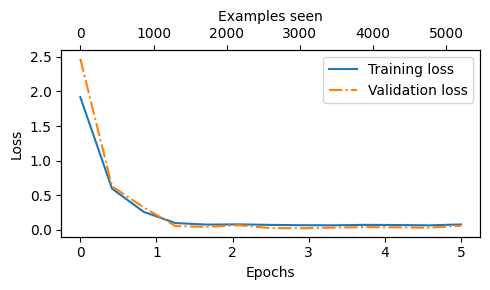

In [34]:
epochs_tensor = mx.linspace(0, num_epochs, len(train_losses))
examples_seen_tensor = mx.linspace(0, examples_seen, len(train_losses))

plot_values(epochs_tensor, examples_seen_tensor, train_losses, val_losses)

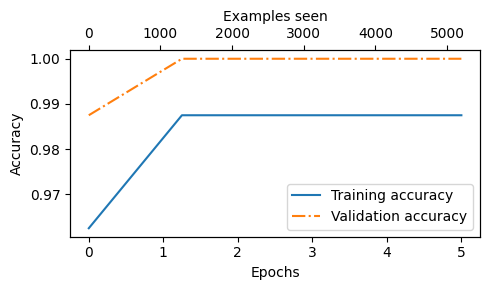

In [35]:
epochs_tensor = mx.linspace(0, num_epochs, len(train_accs))
examples_seen_tensor = mx.linspace(0, examples_seen, len(train_accs))

plot_values(epochs_tensor, examples_seen_tensor, train_accs, val_accs, label="accuracy")

In [36]:
train_accuracy = calc_accuracy_loader(train_loader, model)
val_accuracy = calc_accuracy_loader(val_loader, model)
test_accuracy = calc_accuracy_loader(test_loader, model)

print(f"Training accuracy: {train_accuracy*100:.2f}%")
print(f"Validation accuracy: {val_accuracy*100:.2f}%")
print(f"Test accuracy: {test_accuracy*100:.2f}%")

Training accuracy: 98.56%
Validation accuracy: 98.66%
Test accuracy: 97.67%


In [37]:
def classify_review(text, model, tokenizer, max_length=None, pad_token_id=50256):
    model.eval()

    # Prepare inputs to the model
    input_ids = tokenizer.encode(text)
    supported_context_length = model.context_length
    # Note: In the book, this was originally written as pos_emb.weight.shape[1] by mistake
    # It didn't break the code but would have caused unnecessary truncation (to 768 instead of 1024)

    # Truncate sequences if they too long
    input_ids = input_ids[:min(max_length, supported_context_length)]
    assert max_length is not None, (
        "max_length must be specified. If you want to use the full model context, "
        "pass max_length=model.pos_emb.weight.shape[0]."
    )
    assert max_length <= supported_context_length, (
        f"max_length ({max_length}) exceeds model's supported context length ({supported_context_length})."
    )    
    # Alternatively, a more robust version is the following one, which handles the max_length=None case better
    # max_len = min(max_length,supported_context_length) if max_length else supported_context_length
    # input_ids = input_ids[:max_len]
    
    # Pad sequences to the longest sequence
    input_ids += [pad_token_id] * (max_length - len(input_ids))
    input_tensor = mx.expand_dims(mx.array(input_ids), axis=0) # add batch dimension

    # Model inference
    logits = model(input_tensor)[:, -1, :]  # Logits of the last output token
    predicted_label = mx.argmax(logits, axis=-1).item()

    # Return the classified result
    return "spam" if predicted_label == 1 else "not spam"

In [38]:
text_1 = (
    "You are a winner you have been specially"
    " selected to receive $1000 cash or a $2000 award."
)

print(classify_review(
    text_1, model, tokenizer, max_length=max_length
))

spam


In [39]:
text_2 = (
    "Hey, just wanted to check if we're still on"
    " for dinner tonight? Let me know!"
)

print(classify_review(
    text_2, model, tokenizer, max_length=max_length
))

not spam


In [40]:
model.save_weights("review_classifier.npz")

In [41]:
model.load_weights("review_classifier.npz")

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.09999999999999998)
  (trf_blocks): Sequential(
    (layers.0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(input_dims=768, output_dims=768, bias=True)
        (W_key): Linear(input_dims=768, output_dims=768, bias=True)
        (W_value): Linear(input_dims=768, output_dims=768, bias=True)
        (out_proj): Linear(input_dims=768, output_dims=768, bias=True)
        (dropout): Dropout(p=0.09999999999999998)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (layers.0): Linear(input_dims=768, output_dims=3072, bias=True)
          (layers.1): GELU()
          (layers.2): Linear(input_dims=3072, output_dims=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.09999999999999998)
    )
    (layers.1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_qu